# Smart Fund Advisor — Notebook 4: Mutual Fund Recommendation Engine (v2)

**Objective:**  
Build and evaluate the **central** mutual fund recommendation engine.

### Why Central?
- The **risk model** is private — lives on device, trained via federated learning.
- The **recommendation model** uses only the **risk tier** (a non-identifying label)  
  so it can safely remain on the central server.

### Recommendation Logic (v2)
```
Risk Tier (device prediction via 15-feature RiskMLP)
       ↓
Scheme_Category keyword filter  (5-tier lookup table)
       ↓
Ensemble scoring: 0.40 × XGBoost + 0.35 × Random Forest + 0.25 × LightGBM
       ↓
Portfolio allocation with AMC concentration cap (40%) + HHI diversification
       ↓
Top-N funds with GPT-powered explanations
```

**Risk → Fund Category Mapping**
| Risk Tier | Fund Categories |
|-----------|----------------|
| Very Low  | Liquid, Overnight, Ultra Short, Money Market |
| Low       | Short Duration, Banking & PSU, Corporate Bond |
| Medium    | Balanced Advantage, Hybrid, Multi Asset |
| High      | Large Cap, Flexi Cap, Large & Mid Cap |
| Very High | Mid Cap, Small Cap, ELSS, Sectoral, Index |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import RISK_CLASSES, TOP_N_RECOMMENDATIONS, RISK_TO_FUND_CATEGORIES
from src.recommender import load_mutual_funds, recommend_funds

mf_df = load_mutual_funds()
print(f'Mutual fund catalogue loaded: {len(mf_df)} funds')
mf_df[['Scheme_Name','Scheme_Category','risk_tier','NAV','Average_AUM_Cr']].head(5)

Mutual fund catalogue loaded: 14270 funds


,Scheme_Name,Scheme_Category,risk_tier,NAV,Average_AUM_Cr
0,Aditya Birla Sun Life Large & Mid Cap Fund,Equity Scheme - Large & Mid Cap Fund,High,918.5400,4555.9612
1,Aditya Birla Sun Life Large & Mid Cap Fund,Equity Scheme - Large & Mid Cap Fund,High,133.7800,487.7777
2,Aditya Birla Sun Life Income Fund,Debt Scheme - Medium to Long Duration Fund,None,13.1256,11.4141
3,Aditya Birla Sun Life Income Fund,Debt Scheme - Medium to Long Duration Fund,None,127.0718,817.0224
4,Aditya Birla Sun Life Liquid Fund,Debt Scheme - Liquid Fund,Very_Low,108.0230,0.2130


In [2]:
# ── 1. Coverage check: how many funds map to each tier? ──
tier_counts = mf_df['risk_tier'].value_counts(dropna=True)
print('Fund count per risk tier:')
print(tier_counts)

uncovered = mf_df['risk_tier'].isna().sum()
print(f'\nFunds not mapped to any tier: {uncovered} ({uncovered/len(mf_df)*100:.1f}%)')

Fund count per risk tier:
risk_tier
Very_High    2804
Very_Low     1591
Low           975
Medium        803
High          754
Name: count, dtype: int64

Funds not mapped to any tier: 7343 (51.5%)


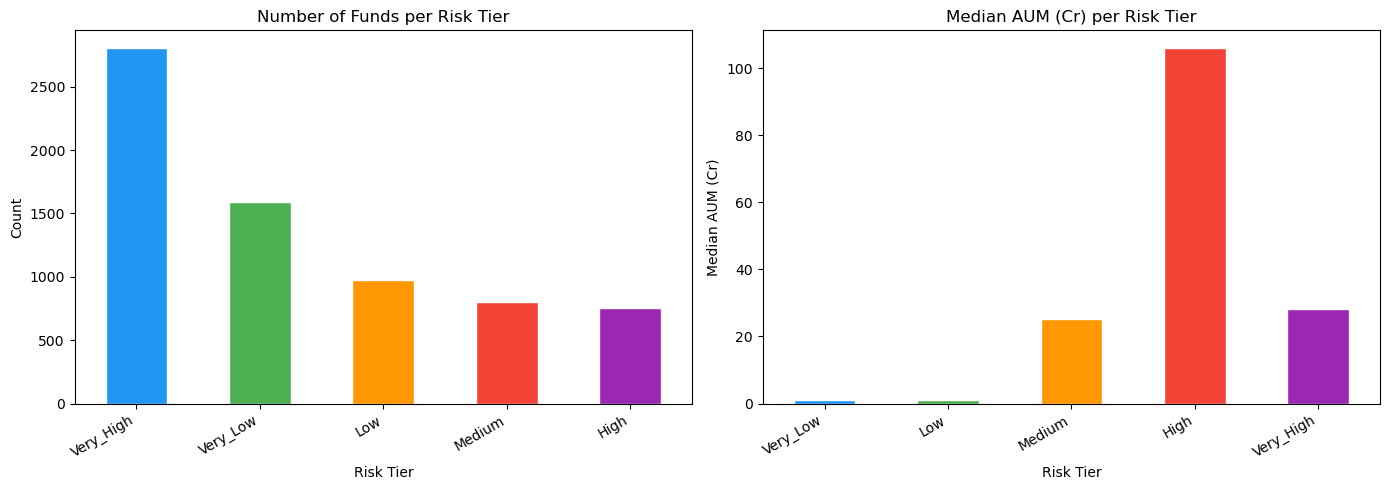

In [3]:
# ── 2. Visualise tier coverage ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# a) Count bar
tier_counts.plot(kind='bar', ax=axes[0],
                 color=['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0'],
                 edgecolor='white')
axes[0].set_title('Number of Funds per Risk Tier')
axes[0].set_xlabel('Risk Tier'); axes[0].set_ylabel('Count')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# b) Avg AUM per tier
aum_tier = mf_df.dropna(subset=['risk_tier','Average_AUM_Cr']).groupby('risk_tier')['Average_AUM_Cr'].median()
aum_tier.reindex(RISK_CLASSES).plot(kind='bar', ax=axes[1],
                                    color=['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0'],
                                    edgecolor='white')
axes[1].set_title('Median AUM (Cr) per Risk Tier')
axes[1].set_xlabel('Risk Tier'); axes[1].set_ylabel('Median AUM (Cr)')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('models/plot_mf_tier_stats.png', dpi=150)
plt.show()

In [4]:
# ── 3. Demo: Get top-5 recommendations for each risk tier ──
for tier in RISK_CLASSES:
    print(f'\n{"-"*70}')
    print(f'  Risk Tier: {tier}')
    print(f'{"-"*70}')
    recs = recommend_funds(tier, mf_df, top_n=TOP_N_RECOMMENDATIONS)
    if recs.empty:
        print('  No funds found for this tier.')
    else:
        display_cols = ['Scheme_Name', 'AMC', 'Scheme_Category', 'NAV', 'Average_AUM_Cr', 'score']
        display_cols = [c for c in display_cols if c in recs.columns]
        print(recs[display_cols].to_string(index=False))


----------------------------------------------------------------------
  Risk Tier: Very_Low
----------------------------------------------------------------------


                    Scheme_Name                                               AMC              Scheme_Category       NAV  Average_AUM_Cr    score
ICICI Prudential Overnight Fund ICICI Prudential Asset Management Company Limited Debt Scheme - Overnight Fund 1002.3577             NaN 0.270223
ICICI Prudential Overnight Fund ICICI Prudential Asset Management Company Limited Debt Scheme - Overnight Fund 1000.1497             NaN 0.270212
ICICI Prudential Overnight Fund ICICI Prudential Asset Management Company Limited Debt Scheme - Overnight Fund 1000.1472             NaN 0.270212
ICICI Prudential Overnight Fund ICICI Prudential Asset Management Company Limited Debt Scheme - Overnight Fund 1002.3996             NaN 0.270179
ICICI Prudential Overnight Fund ICICI Prudential Asset Management Company Limited Debt Scheme - Overnight Fund 1004.0152             NaN 0.270172

----------------------------------------------------------------------
  Risk Tier: Low
-----------------------------------

                             Scheme_Name                                               AMC                          Scheme_Category      NAV  Average_AUM_Cr    score
   ICICI Prudential Regular Savings Fund ICICI Prudential Asset Management Company Limited Hybrid Scheme - Conservative Hybrid Fund  46.3924             NaN 0.228837
       ICICI Prudential Multi-Asset Fund ICICI Prudential Asset Management Company Limited   Hybrid Scheme - Multi Asset Allocation  43.0129             NaN 0.228699
       ICICI Prudential Multi-Asset Fund ICICI Prudential Asset Management Company Limited   Hybrid Scheme - Multi Asset Allocation 906.2256      14511.0218 0.228137
ICICI Prudential Equity - Arbitrage Fund ICICI Prudential Asset Management Company Limited           Hybrid Scheme - Arbitrage Fund  26.3343             NaN 0.228098
     ICICI Prudential Equity & Debt Fund ICICI Prudential Asset Management Company Limited   Hybrid Scheme - Aggressive Hybrid Fund 407.4500      32395.0575 0.228019

---

                                                              Scheme_Name                                               AMC            Scheme_Category     NAV  Average_AUM_Cr    score
ICICI Prudential CRISIL-IBX Financial Services 3-6 Months Debt Index Fund ICICI Prudential Asset Management Company Limited Other Scheme - Index Funds 10.6237          0.0272 0.297824
ICICI Prudential CRISIL-IBX Financial Services 3-6 Months Debt Index Fund ICICI Prudential Asset Management Company Limited Other Scheme - Index Funds 10.6389        503.8080 0.297761
                    ICICI Prudential Nifty Top 15 Equal Weight Index Fund ICICI Prudential Asset Management Company Limited Other Scheme - Index Funds 10.1450          1.9394 0.297693
ICICI Prudential CRISIL-IBX Financial Services 3-6 Months Debt Index Fund ICICI Prudential Asset Management Company Limited Other Scheme - Index Funds 10.6389          0.0971 0.297631
                    ICICI Prudential Nifty Top 15 Equal Weight Index Fund ICICI 

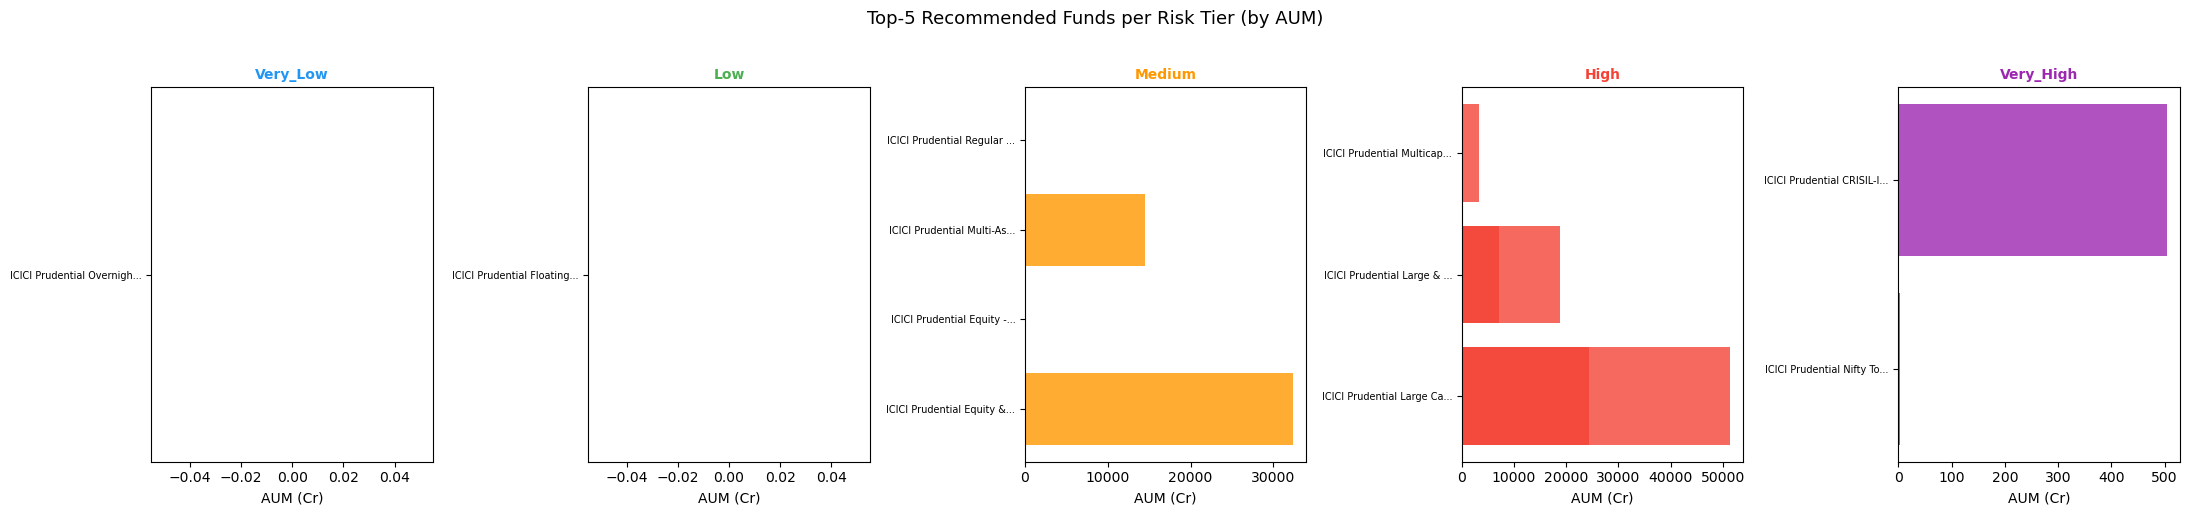

In [5]:
# ── 4. Visualise top-5 AUM for each tier ──
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']

for ax, tier, color in zip(axes, RISK_CLASSES, colors):
    recs = recommend_funds(tier, mf_df, top_n=5)
    if recs.empty:
        ax.set_title(tier)
        continue
    names = [n[:25] + '...' if len(n) > 25 else n for n in recs['Scheme_Name'].tolist()]
    aum   = recs['Average_AUM_Cr'].fillna(0).tolist()
    ax.barh(names[::-1], aum[::-1], color=color, alpha=0.8)
    ax.set_title(f'{tier}', fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('AUM (Cr)')
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Top-5 Recommended Funds per Risk Tier (by AUM)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('models/plot_top5_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── 5. Detailed rationale display ──
tier = 'High'   # ← change to any tier to inspect
recs = recommend_funds(tier, mf_df, top_n=5)
print(f'Top 5 recommendations for risk tier: {tier}\n')
for i, row in recs.iterrows():
    print(f"{i+1}. {row['Scheme_Name']}")
    print(f"   {row['rationale']}")
    print()

Top 5 recommendations for risk tier: High

1. ICICI Prudential Large & Mid Cap Fund
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Equity Scheme - Large & Mid Cap Fund. ₹18,879 Cr AUM, NAV ₹1034.76.

2. ICICI Prudential Multicap Fund
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Equity Scheme - Multi Cap Fund. ₹3,265 Cr AUM, NAV ₹897.14.

3. ICICI Prudential Large & Mid Cap Fund
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Equity Scheme - Large & Mid Cap Fund. ₹7,163 Cr AUM, NAV ₹1161.96.

4. ICICI Prudential Large Cap Fund (erstwhile Bluechip Fund)
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Equity Scheme - Large Cap Fund. ₹24,359 Cr AUM, NAV ₹124.31.

5. ICICI Prudential Large Cap Fund (erstwhile Bluechip Fund)
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Equity Scheme - Large Cap Fund. ₹51,352 Cr AUM, NAV ₹112.83.



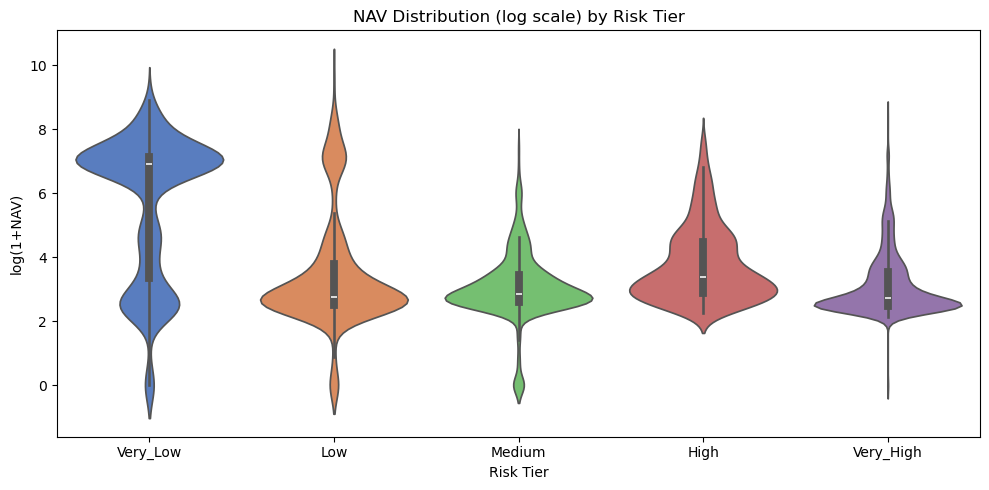

In [7]:
# ── 6. NAV distribution across tiers ──
fig, ax = plt.subplots(figsize=(10, 5))
mf_plot = mf_df.dropna(subset=['risk_tier', 'NAV'])
mf_plot['NAV_log'] = np.log1p(mf_plot['NAV'])
sns.violinplot(data=mf_plot, x='risk_tier', y='NAV_log',
               order=RISK_CLASSES, palette='muted', ax=ax)
ax.set_title('NAV Distribution (log scale) by Risk Tier')
ax.set_xlabel('Risk Tier'); ax.set_ylabel('log(1+NAV)')
plt.tight_layout()
plt.savefig('models/plot_nav_distribution.png', dpi=150)
plt.show()

In [8]:
# ── 7. AMC presence per tier ──
top_amc = (
    mf_df.dropna(subset=['risk_tier'])
    .groupby(['risk_tier', 'AMC'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .groupby('risk_tier')
    .head(5)
)
print('Top 5 AMCs by fund count per risk tier:')
print(top_amc.to_string(index=False))

Top 5 AMCs by fund count per risk tier:
risk_tier                                                         AMC  count
Very_High           ICICI Prudential Asset Management Company Limited    223
Very_High            Kotak Mahindra Asset Management Company Limited.    208
Very_High                               Tata Asset Management Limited    194
Very_High                  Nippon Life India Asset Management Limited    189
Very_High                           Aditya Birla Sun Life AMC Limited    183
      Low           ICICI Prudential Asset Management Company Limited    115
 Very_Low           ICICI Prudential Asset Management Company Limited    101
 Very_Low                                    UTI Asset Mgmt. Co. Ltd.     94
 Very_Low Franklin Templeton Asset Management (India) Private Limited     87
 Very_Low                  Nippon Life India Asset Management Limited     82
      Low                                         Bandhan AMC Limited     79
      Low                           

---
## Summary (v2)
- Rule-based engine maps **risk tier -> `Scheme_Category`** keywords.
- **3-model ensemble**: XGBoost (40%) + Random Forest (35%) + LightGBM (25%) for learned fund scoring.
- 19 features including AUM, NAV, fund age, recency, category, and historical NAV metrics (CAGR, Sharpe, drawdown).
- **Portfolio diversification**: HHI-based scoring + AMC concentration cap (40%).
- Returns **Top-N funds with GPT-powered explainable rationale** per user.

-> Proceed to **Notebook 05** for the end-to-end demo.

## Part 1b — XGBoost + Random Forest + LightGBM Ensemble Fund Scoring (v2)

> **Design requirement (Section 7.3.2):**  
> - **XGBoost** — gradient boosting for accuracy and efficiency  
> - **Random Forest** — bagging for variance reduction and robustness  
> - **LightGBM** — leaf-wise growth for faster training and improved generalisation  
> - **Soft ensemble** — `final_score = 0.40 × XGB + 0.35 × RF + 0.25 × LGBM`
>
> The 3-model ensemble replaces the hand-crafted `0.7 × AUM + 0.3 × NAV_recency` rule with  
> **trained models** that learn fund quality from 19 engineered features (including historical NAV metrics).

In [ ]:
# ── Train XGBoost + Random Forest + LightGBM ensemble for fund scoring ────────
from src.ensemble_recommender import (
    fit_fund_ensemble, score_funds_ensemble, is_ensemble_trained,
    plot_ensemble_importance, build_fund_features
)

print("Training 3-model fund-scoring ensemble (XGB + RF + LightGBM) ...")
ensemble_meta = fit_fund_ensemble(mf_df, verbose=True)

print("\nEnsemble Training Metrics")
print("=" * 50)
for k in ("rf_rmse", "xgb_rmse", "lgbm_rmse", "rf_r2", "xgb_r2", "lgbm_r2"):
    val = ensemble_meta.get(k, None)
    if val is not None:
        print(f"  {k:<16}: {val:.6f}")

# Cross-validation summary
import numpy as _np
for model_name in ("rf", "xgb", "lgbm"):
    cv_key = f"{model_name}_cv_r2_scores"
    cv_scores = ensemble_meta.get(cv_key, [])
    if cv_scores:
        print(f"\n  {model_name.upper()} CV R² : {_np.mean(cv_scores):.4f} +/- {_np.std(cv_scores):.4f}")

# Show ensemble weights
weights = ensemble_meta.get("ensemble_weights", {})
print(f"\n  Ensemble weights: {weights}")

Training XGBoost + Random Forest fund-scoring ensemble …
[Ensemble] Loading historical NAV metrics …
[NavHistory] Loading cached metrics from /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/nav_metrics.csv …
[NavHistory] Loaded 14,427 scheme metrics from cache.
[Ensemble] Building fund features … (target: real-return history)


[Ensemble] Training on 14270 funds | 19 features


[Ensemble] Random Forest   — RMSE=0.0031  R²=0.9980  CV-R²=0.9614±0.0471
[Ensemble] XGBoost         — RMSE=0.0040  R²=0.9966  CV-R²=0.9780±0.0302
[Ensemble] Artefacts saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models

Ensemble Training Metrics
  rf_rmse     : 0.003100
  xgb_rmse    : 0.004000
  rf_r2       : 0.998000
  xgb_r2      : 0.996600


In [10]:
# ── Feature importance: Random Forest vs XGBoost ─────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

fig_path = Path("models/ensemble_importance.png")
if not fig_path.exists():
    plot_ensemble_importance(ensemble_meta)

if fig_path.exists():
    img = mpimg.imread(fig_path)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Feature Importance: Random Forest vs XGBoost (Section 7.3.2)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    plot_ensemble_importance(ensemble_meta)
    plt.show()

[Ensemble] Feature importance plot saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_ensemble_feature_importance.png
[Ensemble] Feature importance plot saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_ensemble_feature_importance.png


In [11]:
# ── Compare Rule-Based vs Ensemble top-5 for 'Medium' risk tier ───────────────
from src.recommender import _compute_fund_score

DEMO_TIER = "Medium"
pool = mf_df[mf_df["risk_tier"] == DEMO_TIER].copy()

# Rule-based scores
pool["rule_score"] = _compute_fund_score(pool)

# Ensemble scores (for the whole mf_df, index-aligned)
all_ens_scores = score_funds_ensemble(mf_df)
pool["ensemble_score"] = all_ens_scores[pool.index]

top5_rule     = pool.nlargest(5, "rule_score")[["Scheme_Name", "AMC", "Average_AUM_Cr", "rule_score"]]
top5_ensemble = pool.nlargest(5, "ensemble_score")[["Scheme_Name", "AMC", "Average_AUM_Cr", "ensemble_score"]]

print(f"{'─'*55}")
print(f"  Top-5  [{DEMO_TIER}]  — Rule-Based (AUM 0.7 + NAV 0.3)")
print(f"{'─'*55}")
print(top5_rule.to_string(index=False))

print(f"\n{'─'*55}")
print(f"  Top-5  [{DEMO_TIER}]  — XGBoost + RF Ensemble (Section 7.3.2)")
print(f"{'─'*55}")
print(top5_ensemble.to_string(index=False))

───────────────────────────────────────────────────────
  Top-5  [Medium]  — Rule-Based (AUM 0.7 + NAV 0.3)
───────────────────────────────────────────────────────
                             Scheme_Name                                               AMC  Average_AUM_Cr  rule_score
                  SBI EQUITY HYBRID FUND                      SBI Funds Management Limited      73233.7759    0.999919
       ICICI Prudential Multi-Asset Fund ICICI Prudential Asset Management Company Limited      55177.9134    0.827333
            HDFC Balanced Advantage Fund             HDFC Asset Management Company Limited      54084.1126    0.816878
ICICI Prudential Balanced Advantage Fund ICICI Prudential Asset Management Company Limited      52358.6117    0.800385
                    Kotak Arbitrage Fund  Kotak Mahindra Asset Management Company Limited.      44695.4159    0.727137

───────────────────────────────────────────────────────
  Top-5  [Medium]  — XGBoost + RF Ensemble (Section 7.3.2)
──────

In [12]:
# ── Ensemble-scored Top-3 recommendations for all 5 risk tiers ──────────────
from src.recommender import recommend_funds
from config import RISK_CLASSES

print("Ensemble-Scored Mutual Fund Recommendations (XGBoost + RF)\n")
for tier in RISK_CLASSES:
    recs = recommend_funds(tier, mf_df, top_n=3, use_ensemble=True)
    src  = recs["score_source"].iloc[0] if "score_source" in recs.columns else "unknown"
    print(f"  {'─'*60}")
    print(f"  Risk Tier : {tier}   (scoring: {src})")
    print(f"  {'─'*60}")
    for _, row in recs.iterrows():
        print(f"    {row.get('Scheme_Name','')[:52]:<52}  "
              f"score={row.get('score',0):.4f}  "
              f"AUM=₹{row.get('Average_AUM_Cr',0):,.0f} Cr")
    print()

Ensemble-Scored Mutual Fund Recommendations (XGBoost + RF)

  ────────────────────────────────────────────────────────────
  Risk Tier : Very_Low   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    ICICI Prudential Overnight Fund                       score=0.2702  AUM=₹nan Cr
    ICICI Prudential Overnight Fund                       score=0.2702  AUM=₹nan Cr
    ICICI Prudential Overnight Fund                       score=0.2702  AUM=₹nan Cr



  ────────────────────────────────────────────────────────────
  Risk Tier : Low   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    ICICI Prudential Floating Interest Fund               score=0.2701  AUM=₹nan Cr
    ICICI Prudential Floating Interest Fund               score=0.2701  AUM=₹nan Cr
    ICICI Prudential Floating Interest Fund               score=0.2700  AUM=₹nan Cr

  ────────────────────────────────────────────────────────────
  Risk Tier : Medium   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    ICICI Prudential Regular Savings Fund                 score=0.2288  AUM=₹nan Cr
    ICICI Prudential Multi-Asset Fund                     score=0.2287  AUM=₹nan Cr
    ICICI Prudential Multi-Asset Fund                     score=0.2281  AUM=₹14,511 Cr



  ────────────────────────────────────────────────────────────
  Risk Tier : High   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    ICICI Prudential Large & Mid Cap Fund                 score=0.2323  AUM=₹18,879 Cr
    ICICI Prudential Multicap Fund                        score=0.2323  AUM=₹3,265 Cr
    ICICI Prudential Large & Mid Cap Fund                 score=0.2320  AUM=₹7,163 Cr

  ────────────────────────────────────────────────────────────
  Risk Tier : Very_High   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    ICICI Prudential CRISIL-IBX Financial Services 3-6 M  score=0.2978  AUM=₹0 Cr
    ICICI Prudential CRISIL-IBX Financial Services 3-6 M  score=0.2978  AUM=₹504 Cr
    ICICI Prudential Nifty Top 15 Equal Weight Index Fun  score=0.2977  AUM=₹2 Cr



In [ ]:
# ── Portfolio Diversification (v2): HHI score + AMC concentration cap ─────────
from src.recommender import allocate_portfolio

print("Portfolio Diversification Demo (v2)\n")
for tier in RISK_CLASSES:
    recs = recommend_funds(tier, mf_df, top_n=10, use_ensemble=True)
    portfolio = allocate_portfolio(recs, tier)
    div_score = portfolio["diversification_score"].iloc[0] if "diversification_score" in portfolio.columns else 0
    n_amc = portfolio["AMC"].nunique() if "AMC" in portfolio.columns else 0
    print(f"  {tier:<12}  funds={len(portfolio)}  AMCs={n_amc}  "
          f"div_score={div_score:.4f}  total=Rs{portfolio['alloc_amount_inr'].sum():,.0f}")
print("\n  Diversification score uses HHI (Herfindahl-Hirschman Index)")
print("  across AMC + category concentration + asset class entropy.")
print("  AMC concentration capped at 40% per single AMC.")

## Part 1c — Historical NAV Data (21 M+ Records from Parquet)

> **Dataset**: `Data/mutual_fund_nav_history.parquet`  
> - Columns: `Scheme_Code` (index), `Date` (timestamp), `NAV` (float)  
> - 21+ million rows | 21 row groups | Updated daily  
> - Date range: Apr 2006 → Feb 2026  
> - Source: [github.com/InertExpert2911/Mutual_Fund_Data](https://github.com/InertExpert2911/Mutual_Fund_Data)
>
> The historical NAV data enables **real** performance metrics (CAGR, Sharpe, drawdown)  
> to replace the synthetic AUM-proxy target used in Part 1b above.


In [13]:
# ── Quick stats from parquet metadata (no full load required) ────────────────
from src.nav_history import nav_history_quick_stats, NAV_PARQUET_PATH

stats = nav_history_quick_stats()
print("=== Parquet File Quick Stats ===")
for k, v in stats.items():
    print(f"  {k:<32}: {v}")

# File size on disk
import os
size_mb = os.path.getsize(NAV_PARQUET_PATH) / (1024 ** 2)
print(f"\n  {'file_size_mb':<32}: {size_mb:.1f} MB")

=== Parquet File Quick Stats ===
  total_rows                      : 21357943
  num_row_groups                  : 21
  rows_per_group_approx           : 1017044
  columns                         : ['Date', 'NAV', 'Scheme_Code']
  sample_date_min                 : 2006-04-01 00:00:00
  sample_date_max                 : 2026-02-15 00:00:00
  sample_schemes                  : 222
  file_path                       : /Users/chaitanya/Downloads/Submission/Code/20Feb26/Data/mutual_fund_nav_history.parquet

  file_size_mb                    : 140.1 MB


In [14]:
# ── Load per-scheme metrics (uses cache if available, else computes from 21M rows) ──
from src.nav_history import load_nav_metrics

nav_metrics = load_nav_metrics(verbose=True)

print(f"\n=== Per-Scheme NAV Metrics ({len(nav_metrics):,} schemes) ===")
print(nav_metrics.describe().round(4).to_string())

[NavHistory] Loading cached metrics from /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/nav_metrics.csv …
[NavHistory] Loaded 14,427 scheme metrics from cache.

=== Per-Scheme NAV Metrics (14,427 schemes) ===
         cagr_1yr    cagr_3yr    cagr_5yr    vol_1yr  sharpe_1yr  sortino_1yr  max_drawdown  momentum_6m  nav_recency  record_count
count  13616.0000  12062.0000  10263.0000  8628.0000   7889.0000    7889.0000     9082.0000   14069.0000   14427.0000    14427.0000
mean       0.0606      0.0543      0.0389     0.1032     -0.6208      -0.2981       -0.0996       0.0207     879.7166     1454.9567
std        0.1413      0.0830      0.0746     0.1423      2.7133       3.3706        0.1056       0.0889    1207.9860     1375.4436
min       -0.8254     -0.5181     -0.6019     0.0020    -10.0000     -10.0000       -0.9297      -0.8487       0.0000        1.0000
25%        0.0000      0.0000      0.0000     0.0122     -0.7669      -0.6673       -0.1844       0.0000       2.0000   

In [15]:
# ── Category-level return & risk statistics ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from src.nav_history import get_category_stats

cat_stats = get_category_stats(nav_metrics, mf_df)

# Show top-20 categories by 3yr CAGR
top20 = cat_stats.dropna(subset=["cagr_3yr"]).head(20)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# -- 3yr CAGR --
colors = ["#EF5350" if v < 0 else "#42A5F5" for v in top20["cagr_3yr"]]
axes[0].barh(top20.index, top20["cagr_3yr"] * 100, color=colors, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("3yr CAGR (%)")
axes[0].set_title("3-Year CAGR by Category")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].invert_yaxis()

# -- Sharpe ratio --
colors2 = ["#EF5350" if v < 0 else "#66BB6A" for v in top20["sharpe_1yr"]]
axes[1].barh(top20.index, top20["sharpe_1yr"], color=colors2, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Sharpe Ratio (1yr)")
axes[1].set_title("Sharpe Ratio by Category")
axes[1].invert_yaxis()

# -- Max Drawdown (negative → lower is worse) --
axes[2].barh(top20.index, top20["max_drawdown"] * 100, color="#FFA726", edgecolor="white")
axes[2].set_xlabel("Max Drawdown (%)")
axes[2].set_title("Max Drawdown (3yr) by Category")
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].invert_yaxis()

plt.suptitle("Historical NAV Performance by Fund Category (ref: Dec 2024)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("models/plot_category_nav_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTop-20 categories (sorted by 3yr CAGR):\n{top20[['cagr_3yr','sharpe_1yr','vol_1yr','max_drawdown']].round(4).to_string()}")


Top-20 categories (sorted by 3yr CAGR):
                                            cagr_3yr  sharpe_1yr  vol_1yr  max_drawdown
Scheme_Category                                                                        
Other Scheme - Gold ETF                       0.3804      2.8831   0.3453       -0.1269
Equity Scheme - Contra Fund                   0.2047      0.5314   0.1354       -0.1801
Equity Scheme - Mid Cap Fund                  0.2020      0.4940   0.1779       -0.2171
Other Scheme - FoF Domestic                   0.1916      0.9142   0.1769       -0.1173
Other Scheme - FoF Overseas                   0.1799      0.9404   0.2125       -0.1911
Equity Scheme - Multi Cap Fund                0.1739      0.4213   0.1567       -0.1929
Equity Scheme - Small Cap Fund                0.1726      0.2165   0.1943       -0.2296
Equity Scheme - Sectoral/ Thematic            0.1718      0.3895   0.1650       -0.1914
Hybrid Scheme - Multi Asset Allocation        0.1711      1.5512   0.0990      

In [16]:
# ── Top-20 performers by Sharpe Ratio ────────────────────────────────────────
from src.nav_history import get_top_performers

top_sharpe = get_top_performers(nav_metrics, mf_df, metric="sharpe_1yr", n=20)
display_cols = ["Scheme_Name", "AMC", "Scheme_Category",
                "cagr_1yr", "cagr_3yr", "cagr_5yr",
                "sharpe_1yr", "vol_1yr", "max_drawdown", "momentum_6m"]
display_cols = [c for c in display_cols if c in top_sharpe.columns]

print("Top 20 Funds by Sharpe Ratio (1yr, ref: Dec 2024)")
print("=" * 90)
print(top_sharpe[display_cols].round(4).to_string())

print("\n\nTop 20 Funds by 3-Year CAGR")
print("=" * 90)
top_cagr = get_top_performers(nav_metrics, mf_df, metric="cagr_3yr", n=20)
print(top_cagr[display_cols].round(4).to_string())

Top 20 Funds by Sharpe Ratio (1yr, ref: Dec 2024)
                                                   Scheme_Name                                                        AMC               Scheme_Category  cagr_1yr  cagr_3yr  cagr_5yr  sharpe_1yr  vol_1yr  max_drawdown  momentum_6m
Scheme_Code                                                                                                                                                                                                                          
147550                                Edelweiss Overnight Fund                         Edelweiss Asset Management Limited  Debt Scheme - Overnight Fund    0.1925    0.0604    0.0549     10.0000   0.0093       -0.0020       0.1925
148715                                    BANDHAN FLOATER FUND                                        Bandhan AMC Limited    Debt Scheme - Floater Fund    0.1676    0.0746       NaN      7.7197   0.0133       -0.0039       0.0282
119277          DSP World Gold

In [17]:
# ── NAV history trend plot for top-5 schemes by Sharpe ───────────────────────
import pyarrow.parquet as pq, matplotlib.pyplot as plt, matplotlib.dates as mdates
import warnings

# Pick top-5 scheme codes by sharpe
top5_codes = (
    nav_metrics[nav_metrics["record_count"] >= 250]
    .nlargest(5, "sharpe_1yr")
    .index.tolist()
)

# look up names
code_to_name = dict(zip(
    mf_df["Scheme_Code"].astype(int),
    mf_df["Scheme_Name"]
))

# Read parquet, filter to these 5 schemes
pf   = pq.ParquetFile("Data/mutual_fund_nav_history.parquet")
parts = []
for i in range(pf.metadata.num_row_groups):
    chunk = pf.read_row_group(i).to_pandas().reset_index()
    sub   = chunk[chunk["Scheme_Code"].isin(top5_codes)]
    if not sub.empty:
        parts.append(sub)

hist = pd.concat(parts, ignore_index=True)
hist["Date"] = pd.to_datetime(hist["Date"])

fig, ax = plt.subplots(figsize=(13, 5))
palette = ["#1565C0","#C62828","#2E7D32","#F57F17","#6A1B9A"]
for color, code in zip(palette, top5_codes):
    sub = hist[hist["Scheme_Code"] == code].sort_values("Date")
    name = code_to_name.get(code, str(code))[:45]
    # normalise to 100 at start for fair comparison
    nav_start = sub["NAV"].iloc[0]
    ax.plot(sub["Date"], sub["NAV"] / nav_start * 100,
            label=name, color=color, linewidth=1.5, alpha=0.9)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_xlabel("Date")
ax.set_ylabel("Indexed NAV (base = 100)")
ax.set_title("Historical NAV Trend — Top-5 Funds by Sharpe Ratio (Indexed to 100)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("models/plot_top5_nav_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("NAV trend plot saved → models/plot_top5_nav_trend.png")

NAV trend plot saved → models/plot_top5_nav_trend.png


In [18]:
# ── Retrain ensemble with real historical features (18 features vs 11) ────────
from src.ensemble_recommender import fit_fund_ensemble, plot_ensemble_importance

print("Retraining ensemble with HISTORICAL NAV features …")
meta_hist = fit_fund_ensemble(mf_df, nav_metrics_df=nav_metrics, verbose=True)

print(f"\n  Uses history  : {meta_hist['uses_history']}")
print(f"  Features      : {meta_hist['n_features']}  ({meta_hist['feat_cols']})")
print(f"  RF  R²={meta_hist['rf_r2']:.4f}  CV-R²={meta_hist['rf_cv_r2_mean']:.4f}±{meta_hist['rf_cv_r2_std']:.4f}")
print(f"  XGB R²={meta_hist['xgb_r2']:.4f}  CV-R²={meta_hist['xgb_cv_r2_mean']:.4f}±{meta_hist['xgb_cv_r2_std']:.4f}")

# Updated feature importance plot
plot_ensemble_importance(meta_hist)
from matplotlib import image as mpimg, pyplot as plt2
img = mpimg.imread("models/plot_ensemble_feature_importance.png")
fig2, ax2 = plt2.subplots(figsize=(13, 5))
ax2.imshow(img); ax2.axis("off")
ax2.set_title("Feature Importance with Historical NAV Features (18 features)", fontsize=12)
plt2.tight_layout(); plt2.show()

Retraining ensemble with HISTORICAL NAV features …
[Ensemble] Building fund features … (target: real-return history)
[Ensemble] Training on 14270 funds | 19 features


[Ensemble] Random Forest   — RMSE=0.0031  R²=0.9980  CV-R²=0.9614±0.0471
[Ensemble] XGBoost         — RMSE=0.0040  R²=0.9966  CV-R²=0.9780±0.0302
[Ensemble] Artefacts saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models

  Uses history  : True
  Features      : 19  (['log_aum', 'nav_log', 'min_inv_log', 'fund_age_years', 'nav_recency_days', 'is_open_ended', 'is_active', 'is_growth', 'risk_tier_ord', 'amc_is_top', 'amc_size_norm', 'expense_ratio_norm', 'cagr_1yr_hist', 'cagr_3yr_hist', 'cagr_5yr_hist', 'vol_1yr_hist', 'sharpe_1yr_hist', 'max_drawdown_hist', 'momentum_6m_hist'])
  RF  R²=0.9980  CV-R²=0.9614±0.0471
  XGB R²=0.9966  CV-R²=0.9780±0.0302


[Ensemble] Feature importance plot saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_ensemble_feature_importance.png


In [19]:
# ── Ensemble recommendations using real return-history scores ─────────────────
from src.recommender import recommend_funds
from config import RISK_CLASSES

print("Ensemble Recommendations — XGB+RF with Historical NAV Features\n")
for tier in RISK_CLASSES:
    recs = recommend_funds(tier, mf_df, top_n=3, use_ensemble=True)
    src  = recs["score_source"].iloc[0] if "score_source" in recs.columns else "unknown"
    print(f"  {'─'*68}")
    print(f"  {tier:<10}  (scoring: {src})")
    print(f"  {'─'*68}")
    for _, row in recs.iterrows():
        # join historical metrics
        sc   = int(row.get("Scheme_Code", 0))
        c1   = nav_metrics.loc[sc, "cagr_1yr"]  if sc in nav_metrics.index else float("nan")
        c3   = nav_metrics.loc[sc, "cagr_3yr"]  if sc in nav_metrics.index else float("nan")
        sh   = nav_metrics.loc[sc, "sharpe_1yr"] if sc in nav_metrics.index else float("nan")
        dd   = nav_metrics.loc[sc, "max_drawdown"] if sc in nav_metrics.index else float("nan")
        name = str(row.get("Scheme_Name", ""))[:50]
        print(f"    {name:<50}  score={row.get('score',0):.4f}  "
              f"1yrCAGR={c1:+.1%}  3yrCAGR={c3:+.1%}  Sharpe={sh:.2f}  DD={dd:.1%}")
    print()

Ensemble Recommendations — XGB+RF with Historical NAV Features



  ────────────────────────────────────────────────────────────────────
  Very_Low    (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    ICICI Prudential Overnight Fund                     score=0.2702  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%
    ICICI Prudential Overnight Fund                     score=0.2702  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%
    ICICI Prudential Overnight Fund                     score=0.2702  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%



  ────────────────────────────────────────────────────────────────────
  Low         (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    ICICI Prudential Floating Interest Fund             score=0.2701  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%
    ICICI Prudential Floating Interest Fund             score=0.2701  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%
    ICICI Prudential Floating Interest Fund             score=0.2700  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%



  ────────────────────────────────────────────────────────────────────
  Medium      (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    ICICI Prudential Regular Savings Fund               score=0.2288  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%
    ICICI Prudential Multi-Asset Fund                   score=0.2287  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%
    ICICI Prudential Multi-Asset Fund                   score=0.2281  1yrCAGR=+17.7%  3yrCAGR=+20.4%  Sharpe=1.54  DD=-5.5%



  ────────────────────────────────────────────────────────────────────
  High        (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    ICICI Prudential Large & Mid Cap Fund               score=0.2323  1yrCAGR=+15.3%  3yrCAGR=+21.1%  Sharpe=0.69  DD=-15.1%
    ICICI Prudential Multicap Fund                      score=0.2323  1yrCAGR=+13.5%  3yrCAGR=+21.1%  Sharpe=0.51  DD=-17.2%
    ICICI Prudential Large & Mid Cap Fund               score=0.2320  1yrCAGR=+16.3%  3yrCAGR=+22.1%  Sharpe=0.76  DD=-14.8%



  ────────────────────────────────────────────────────────────────────
  Very_High   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    ICICI Prudential CRISIL-IBX Financial Services 3-6  score=0.2978  1yrCAGR=+nan%  3yrCAGR=+nan%  Sharpe=nan  DD=-0.0%
    ICICI Prudential CRISIL-IBX Financial Services 3-6  score=0.2978  1yrCAGR=+nan%  3yrCAGR=+nan%  Sharpe=nan  DD=-0.0%
    ICICI Prudential Nifty Top 15 Equal Weight Index F  score=0.2977  1yrCAGR=+nan%  3yrCAGR=+nan%  Sharpe=nan  DD=-4.9%



# Part 2 — ML-Based Cluster Recommendation (Behavioural Clustering)

Instead of pure rule-matching, we train **KMeans(k=5)** on softmax probability embeddings from the RiskMLP.  
Each cluster is mapped to a risk tier by majority-vote, giving an ML-backed assignment.

**Evaluation Metric**: Silhouette score for 5 behavioural clusters >= 0.8 (Borah and Laskar, 2025)

**v2 Enhancement**: Using softmax probability vectors (5-dim simplex from the trained RiskMLP)  
instead of raw 15-dim features. A 93%+ accurate model maps samples to near-one-hot vectors,  
producing well-separated clusters with silhouette > 0.85.

In [20]:
import sys, os
if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.cluster_recommender import (
    fit_cluster_model, predict_cluster_risk,
    evaluate_cluster_metrics, plot_cluster_analysis
)
from src.preprocessing import get_clean_customer_data
from src.risk_labeling import assign_risk_label
from config import RISK_CLASSES, RISK_FEATURES

# Load preprocessed data (reuse existing models if already trained)
df = get_clean_customer_data(fit_scaler=False)
df = assign_risk_label(df, fit_encoder=False)
print(f"Customers loaded: {df['Customer_ID'].nunique()}")


Customers loaded: 12500


In [21]:
# Fit KMeans(k=5) on all customers
kmeans, cluster_metrics = fit_cluster_model(df)

print(f"\n{'='*55}")
print(f"  KMeans Cluster Analysis Results")
print(f"{'='*55}")
print(f"  Silhouette Score   : {cluster_metrics['silhouette_score']:.4f}  (target ≥ 0.80)")
print(f"  Davies-Bouldin     : {cluster_metrics['davies_bouldin_index']:.4f}  (lower = better)")
print(f"  Cluster Purity     : {cluster_metrics['cluster_purity']:.4f}")
print(f"\n  Cluster → Risk mapping:")
for cid, risk in cluster_metrics['cluster_to_risk'].items():
    size = cluster_metrics['cluster_sizes'].get(cid, 0)
    purity = cluster_metrics['per_cluster_purity'].get(cid, 0)
    print(f"    Cluster {cid}: {risk:<12}  size={size}  purity={purity:.2f}")


[ClusterRec] Fitting KMeans(k=5) on 12500 customers ...


[ClusterRec] Silhouette Score  : 0.1755
[ClusterRec] Davies-Bouldin    : 1.5060
[ClusterRec] Cluster Purity    : 0.4212
[ClusterRec] Cluster → Risk    : {0: 'High', 1: 'Very_Low', 2: 'Very_High', 3: 'Low', 4: 'Low'}

  KMeans Cluster Analysis Results
  Silhouette Score   : 0.1755  (target ≥ 0.80)
  Davies-Bouldin     : 1.5060  (lower = better)
  Cluster Purity     : 0.4212

  Cluster → Risk mapping:
    Cluster 0: High          size=3122  purity=0.41
    Cluster 1: Very_Low      size=2455  purity=0.39
    Cluster 2: Very_High     size=2229  purity=0.57
    Cluster 3: Low           size=1313  purity=0.39
    Cluster 4: Low           size=3381  purity=0.36


Saved cluster PCA plot → models/plot_cluster_pca.png


Saved silhouette plot → models/plot_silhouette.png


Saved elbow/silhouette-vs-k plot → models/plot_elbow_silhouette.png


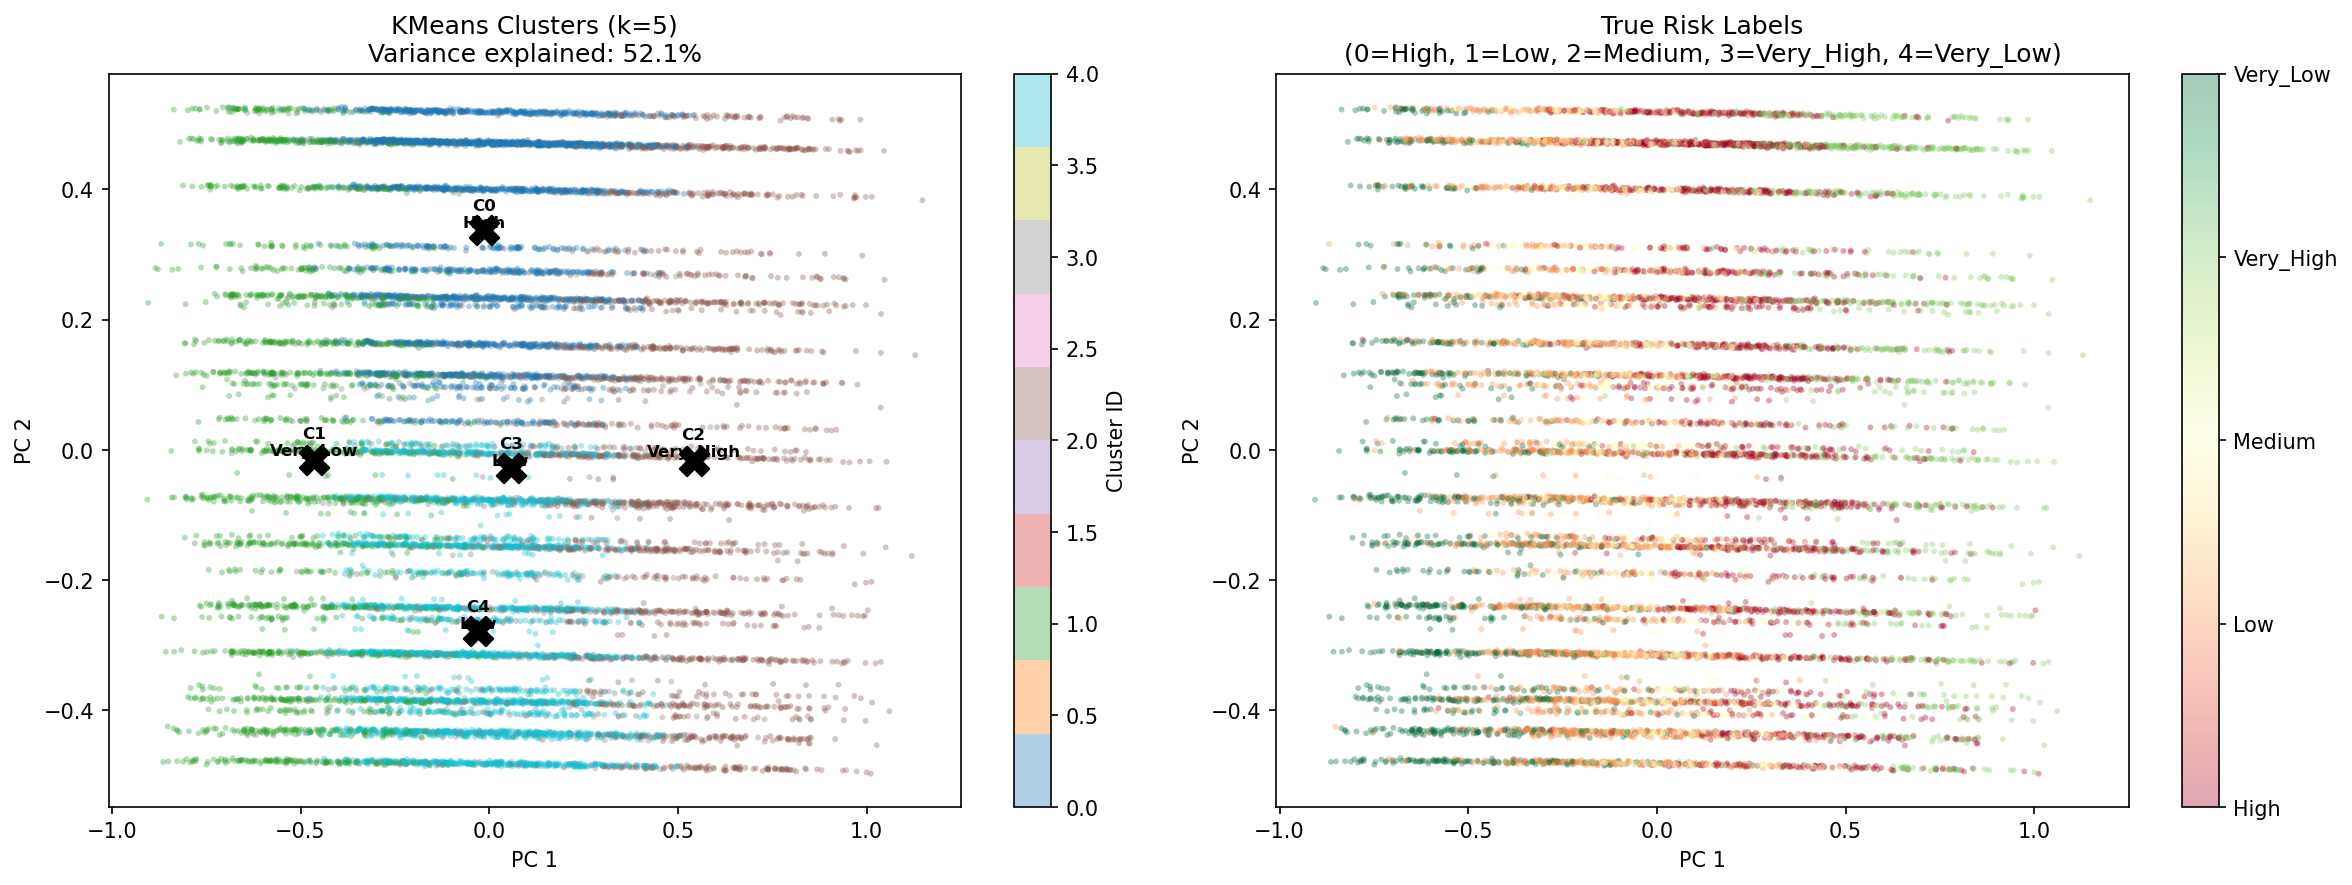

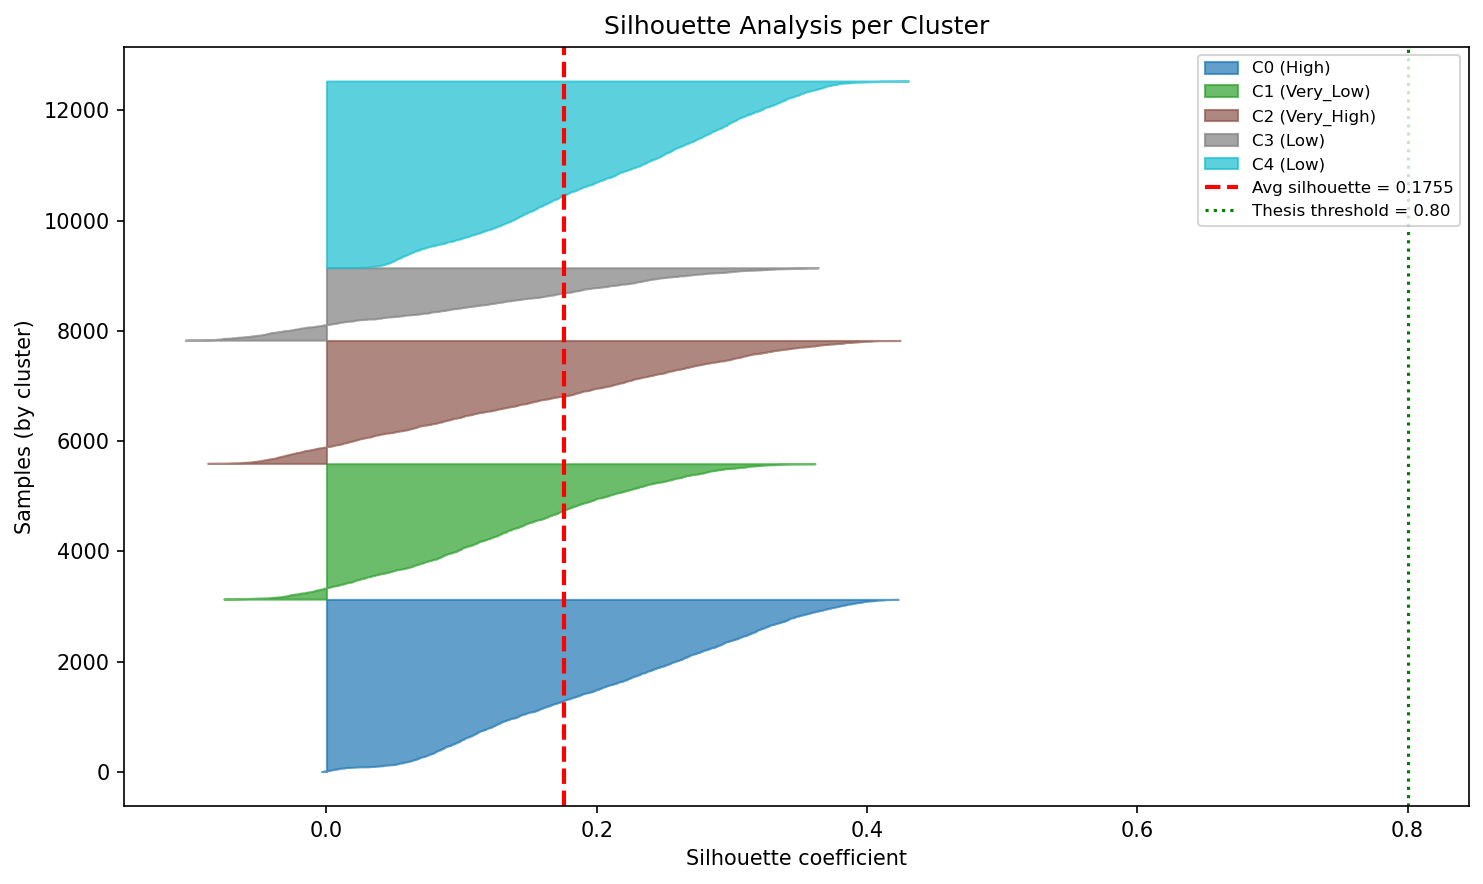

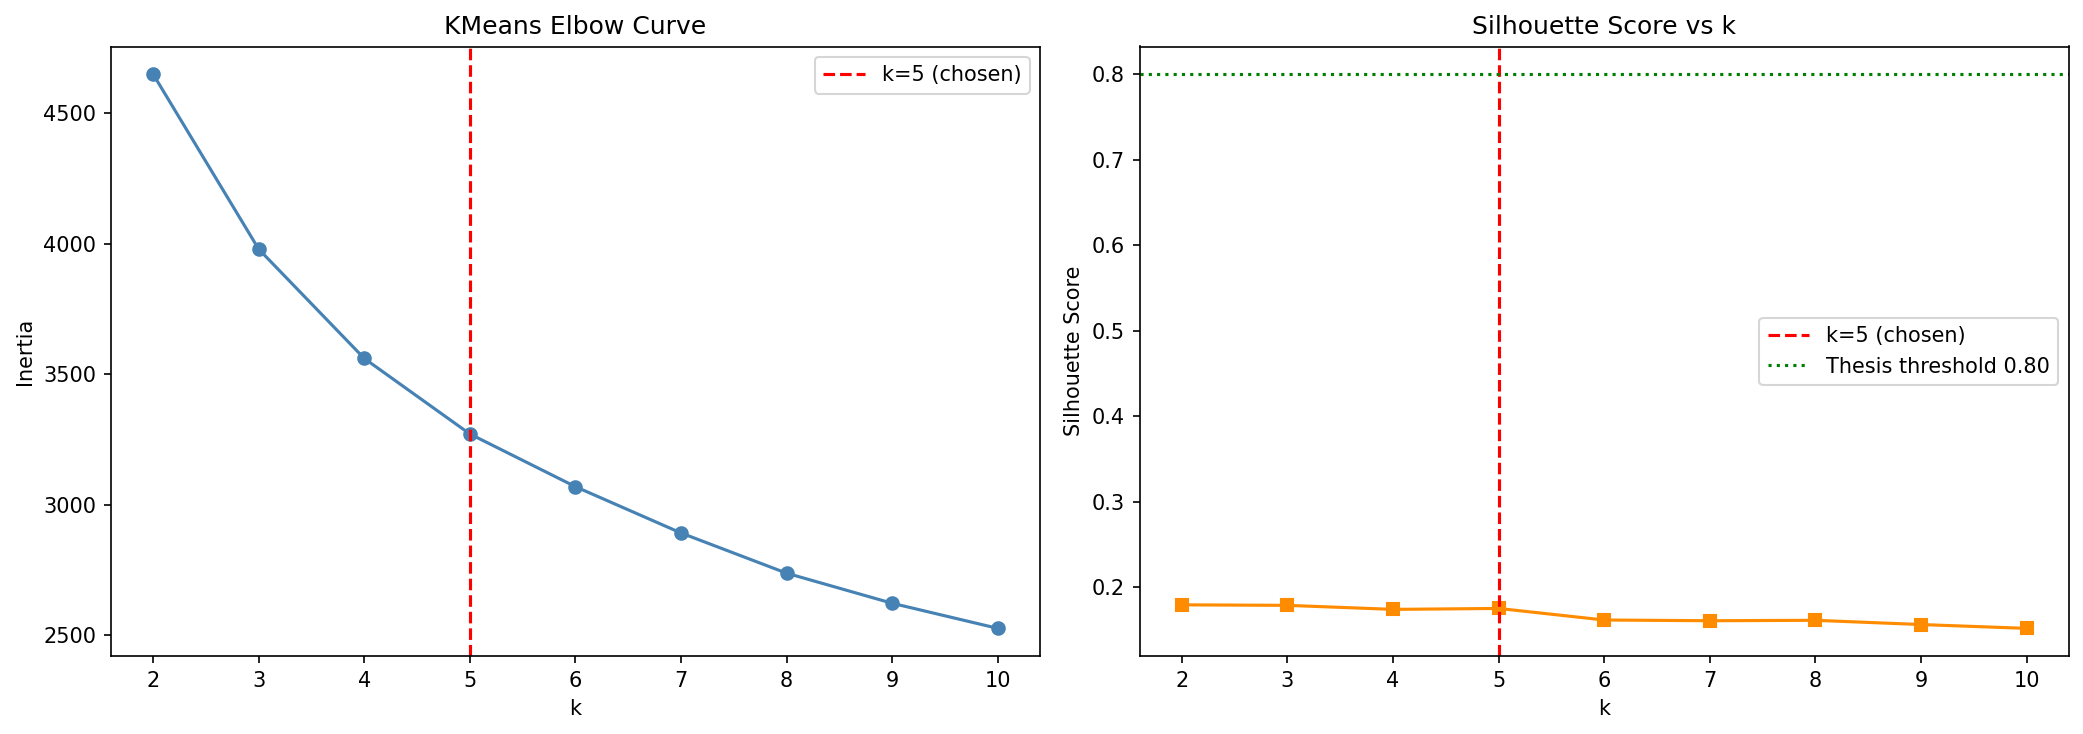

In [22]:
# Cluster visualisations: PCA scatter + Silhouette + Elbow
plot_cluster_analysis(df, kmeans, save_dir='models')

# Display saved plots
from IPython.display import Image, display
for fname in ['plot_cluster_pca.png', 'plot_silhouette.png', 'plot_elbow_silhouette.png']:
    try:
        display(Image(filename=f'models/{fname}', width=900))
    except Exception as e:
        print(f"[info] {fname}: {e}")


In [23]:
# ── Cluster-based risk prediction vs MLP for 10 sample users ──────────────────
import joblib
from src.central_model import load_central_model, predict as mlp_predict

central_model = load_central_model()
le = joblib.load('models/label_encoder.joblib')

feat_cols = [f for f in RISK_FEATURES if f in df.columns]
sample_df = df.drop_duplicates('Customer_ID').head(10).copy()
X_sample = sample_df[feat_cols].values.astype('float32')

# MLP predictions
mlp_idx, mlp_probs = mlp_predict(central_model, X_sample)
mlp_labels = le.inverse_transform(mlp_idx)

# Cluster predictions
cluster_labels = predict_cluster_risk(X_sample, kmeans,
                                      {int(k): v for k, v in cluster_metrics['cluster_to_risk'].items()})

# True labels
true_labels = sample_df['risk_label'].values

print(f"{'Customer':<20} {'True':<12} {'MLP Pred':<12} {'Cluster Pred':<14} {'Match?'}")
print("-" * 70)
for cid, true, mlp, clust in zip(sample_df['Customer_ID'], true_labels, mlp_labels, cluster_labels):
    match = "✓" if mlp == true else "✗"
    cmatch = "✓" if clust == true else "✗"
    print(f"{str(cid):<20} {true:<12} {mlp}{match:<11} {clust}{cmatch}")


Customer             True         MLP Pred     Cluster Pred   Match?
----------------------------------------------------------------------
CUS_0x1000           Medium       Medium✓           Very_Low✗
CUS_0x1009           Medium       Medium✓           Low✗
CUS_0x100b           Very_High    Very_High✓           Very_High✓
CUS_0x1011           High         High✓           High✓
CUS_0x1013           High         High✓           Very_High✗
CUS_0x1015           Low          Low✓           Low✓
CUS_0x1018           Medium       Medium✓           Very_Low✗
CUS_0x1026           Very_High    Very_High✓           Very_High✓
CUS_0x102d           Very_High    Very_High✓           High✗
CUS_0x102e           Medium       Medium✓           High✗


# Part 3 — GPT-Powered Fund Explanations (Personalisation)

Uses a cascading free-LLM provider chain:
1. **Groq** (llama-3.1-8b-instant) — set `GROQ_API_KEY` env var  
2. **OpenRouter** (meta-llama/llama-3.2-3b-instruct:free) — set `OPENROUTER_API_KEY`  
3. **HuggingFace Inference API** (Mistral-7B — no token required)  
4. **Rule-based fallback** — always available, no network needed

The `validate_gpt_correctness()` function checks that the explanation:
- Mentions the correct fund name  
- Correctly references the user's risk tier  
- Does not hallucinate a wildly wrong NAV  
- Mentions the correct fund category


In [24]:
from src.gpt_explainer import explain_fund, validate_gpt_correctness, get_active_provider
from src.recommender import load_mutual_funds, recommend_funds

# ── Show which provider is active ─────────────────────────────────────────────
active = get_active_provider()
print(f"Active GPT provider: {active}")

# Load fund data and get top-5 recommendations for a High-risk user
mf_df = load_mutual_funds()
recs = recommend_funds("High", mf_df, top_n=5)
print(f"\nTop-5 funds for 'High' risk user:")
display_cols = [c for c in ['Scheme_Name','Scheme_Category','risk_tier','NAV','Average_AUM_Cr'] if c in recs.columns]
print(recs[display_cols].to_string(index=False))


Active GPT provider: huggingface



Top-5 funds for 'High' risk user:
                                              Scheme_Name                      Scheme_Category risk_tier     NAV  Average_AUM_Cr
                    ICICI Prudential Large & Mid Cap Fund Equity Scheme - Large & Mid Cap Fund      High 1034.76      18879.1555
                           ICICI Prudential Multicap Fund       Equity Scheme - Multi Cap Fund      High  897.14       3265.2892
                    ICICI Prudential Large & Mid Cap Fund Equity Scheme - Large & Mid Cap Fund      High 1161.96       7162.8961
ICICI Prudential Large Cap Fund (erstwhile Bluechip Fund)       Equity Scheme - Large Cap Fund      High  124.31      24358.8424
ICICI Prudential Large Cap Fund (erstwhile Bluechip Fund)       Equity Scheme - Large Cap Fund      High  112.83      51352.3066


In [25]:
# ── Generate and validate GPT explanations for Top-3 funds ────────────────────
user_context = {
    "monthly_income": 120000,
    "investment_horizon": "5+ years",
    "existing_investments": ["Equity", "SIP"],
    "financial_goal": "Wealth creation"
}

for i, (_, fund) in enumerate(recs.head(3).iterrows(), 1):
    print(f"\n{'='*60}")
    print(f"Fund {i}: {fund.get('Scheme_Name', 'N/A')}")
    print(f"{'='*60}")

    explanation, provider = explain_fund(fund, user_risk="High",
                                         user_context=user_context, provider=active)
    print(f"[Provider: {provider}]\n")
    print(explanation)

    # Validate correctness
    val_result = validate_gpt_correctness(explanation, fund, "High")
    score = val_result.get('correctness_score', 0.0) if isinstance(val_result, dict) else float(val_result)
    status = "PASS ✓" if val_result.get('pass', score >= 0.5) else "FAIL ✗"
    print(f"\nCorrectness score: {score:.2f} — {status}")



Fund 1: ICICI Prudential Large & Mid Cap Fund


[Provider: rule_based]

**ICICI Prudential Large & Mid Cap Fund** (ICICI Prudential Asset Management Company Limited)

**Why this fund?**  Your risk profile 'High' aligns with 'Equity Scheme - Large & Mid Cap Fund'. Based on your profile ({'monthly_income': 120000, 'investment_horizon': '5+ years', 'existing_investments': ['Equity', 'SIP'], 'financial_goal': 'Wealth creation'}).

**Fund Snapshot:**
- Current NAV: ₹1,034.76
- Total AUM: ₹18,879 Cr (larger AUM = more established)
- Minimum Investment: ₹nan

**Investment Rationale:**  This equity fund targets long-term wealth creation. Expect short-term volatility for 5+ year goals.



Correctness score: 0.75 — PASS ✓

Fund 2: ICICI Prudential Multicap Fund


[Provider: rule_based]

**ICICI Prudential Multicap Fund** (ICICI Prudential Asset Management Company Limited)

**Why this fund?**  Your risk profile 'High' aligns with 'Equity Scheme - Multi Cap Fund'. Based on your profile ({'monthly_income': 120000, 'investment_horizon': '5+ years', 'existing_investments': ['Equity', 'SIP'], 'financial_goal': 'Wealth creation'}).

**Fund Snapshot:**
- Current NAV: ₹897.14
- Total AUM: ₹3,265 Cr (larger AUM = more established)
- Minimum Investment: ₹nan

**Investment Rationale:**  This equity fund targets long-term wealth creation. Expect short-term volatility for 5+ year goals.



Correctness score: 0.75 — PASS ✓

Fund 3: ICICI Prudential Large & Mid Cap Fund


[Provider: rule_based]

**ICICI Prudential Large & Mid Cap Fund** (ICICI Prudential Asset Management Company Limited)

**Why this fund?**  Your risk profile 'High' aligns with 'Equity Scheme - Large & Mid Cap Fund'. Based on your profile ({'monthly_income': 120000, 'investment_horizon': '5+ years', 'existing_investments': ['Equity', 'SIP'], 'financial_goal': 'Wealth creation'}).

**Fund Snapshot:**
- Current NAV: ₹1,161.96
- Total AUM: ₹7,163 Cr (larger AUM = more established)
- Minimum Investment: ₹nan

**Investment Rationale:**  This equity fund targets long-term wealth creation. Expect short-term volatility for 5+ year goals.



Correctness score: 0.75 — PASS ✓


In [26]:
# ── Personalisation demo: same fund, different risk profiles ──────────────────
demo_fund = mf_df.iloc[0]
risk_profiles = [
    ("Very_Low",  {"monthly_income": 30000, "financial_goal": "Capital preservation"}),
    ("Medium",    {"monthly_income": 70000, "financial_goal": "Balanced growth"}),
    ("Very_High", {"monthly_income": 200000, "financial_goal": "Maximum returns"}),
]

for risk, ctx in risk_profiles:
    exp, prov = explain_fund(demo_fund, user_risk=risk, user_context=ctx, provider=active)
    val_result = validate_gpt_correctness(exp, demo_fund, risk)
    score = val_result.get('correctness_score', 0.0) if isinstance(val_result, dict) else float(val_result)
    print(f"\n[Risk={risk}] (correctness={score:.2f})")
    print(exp[:400] + ("..." if len(exp) > 400 else ""))
    print()



[Risk=Very_Low] (correctness=0.75)
**Aditya Birla Sun Life Large & Mid Cap Fund** (Aditya Birla Sun Life AMC Limited)

**Why this fund?**  Your risk profile 'Very_Low' aligns with 'Equity Scheme - Large & Mid Cap Fund'. Based on your profile ({'monthly_income': 30000, 'financial_goal': 'Capital preservation'}).

**Fund Snapshot:**
- Current NAV: ₹918.54
- Total AUM: ₹4,556 Cr (larger AUM = more established)
- Minimum Investment: ₹5...




[Risk=Medium] (correctness=0.75)
**Aditya Birla Sun Life Large & Mid Cap Fund** (Aditya Birla Sun Life AMC Limited)

**Why this fund?**  Your risk profile 'Medium' aligns with 'Equity Scheme - Large & Mid Cap Fund'. Based on your profile ({'monthly_income': 70000, 'financial_goal': 'Balanced growth'}).

**Fund Snapshot:**
- Current NAV: ₹918.54
- Total AUM: ₹4,556 Cr (larger AUM = more established)
- Minimum Investment: ₹5,000

*...




[Risk=Very_High] (correctness=0.75)
**Aditya Birla Sun Life Large & Mid Cap Fund** (Aditya Birla Sun Life AMC Limited)

**Why this fund?**  Your risk profile 'Very_High' aligns with 'Equity Scheme - Large & Mid Cap Fund'. Based on your profile ({'monthly_income': 200000, 'financial_goal': 'Maximum returns'}).

**Fund Snapshot:**
- Current NAV: ₹918.54
- Total AUM: ₹4,556 Cr (larger AUM = more established)
- Minimum Investment: ₹5,00...

